<a href="https://colab.research.google.com/github/simply-logical/mlbook_ii_notebooks/blob/master/Hello_simple_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hello-simpleAI Dataset**

In [ ]:
! pip install datasets pyarrow mlcroissant

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.9 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=9b249788f1234e2d58656a38e0c9e504a2978640abe19e26becd1b6e50ff3583
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw


In [ ]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [ ]:
from mlcroissant import Dataset

ds = Dataset(jsonld="https://huggingface.co/api/datasets/Hello-SimpleAI/HC3/croissant")
records = ds.records("wiki_csai")

  -  [Metadata(HC3)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.
  -  [Metadata(HC3)] Property "https://schema.org/datePublished" is recommended, but does not exist.
  -  [Metadata(HC3)] Property "https://schema.org/version" is recommended, but does not exist.


In [ ]:
import pandas as pd

pd.DataFrame(list(records))

,wiki_csai/split,wiki_csai/id,wiki_csai/question,wiki_csai/human_answers,wiki_csai/chatgpt_answers
0,b'train',b'0',"b'Please explain what is ""Animal cognition""'",[b'Animal cognition encompasses the mental cap...,[b'Animal cognition refers to the mental capac...
1,b'train',b'1',"b'Please explain what is ""Human intelligence""'","[b""Human intelligence is the intellectual capa...",[b'Human intelligence is the mental ability to...
2,b'train',b'2',"b'Please explain what is ""Oxford English Dicti...",[b'The Oxford English Dictionary (OED) is the ...,[b'The Oxford English Dictionary (OED) is a co...
3,b'train',b'3',"b'Please explain what is ""Oxford University Pr...","[b""Oxford University Press (OUP) is the univer...","[b""Oxford University Press (OUP) is a departme..."
4,b'train',b'4',"b'Please explain what is ""AI applications""'",[b'Artificial intelligence (AI) has been used ...,[b'AI applications are computer systems that a...
...,...,...,...,...,...
837,b'train',b'837',"b'Please explain what is ""Punched cards""'",[b'A punched card (also punch card or punched-...,[b'Punched cards were a means of storing and p...
838,b'train',b'838',"b'Please explain what is ""Paper tape""'",[b'Punched tape or perforated paper tape is a ...,[b'Paper tape is a medium for storing and tran...
839,b'train',b'839',"b'Please explain what is ""BBC Model B""'",[b'The British Broadcasting Corporation Microc...,[b'The BBC Model B is a computer that was made...
840,b'train',b'840',"b'Please explain what is ""O level""'",[b'The O-Level (Ordinary Level) is a subject-b...,"[b'""O level"" refers to the General Certificate..."


In [ ]:
data = list(records)
data[:10]

[{'wiki_csai/split': b'train',
  'wiki_csai/id': b'0',
  'wiki_csai/question': b'Please explain what is "Animal cognition"',
  'wiki_csai/human_answers': [b'Animal cognition encompasses the mental capacities of non-human animals including insect cognition. The study of animal conditioning and learning used in this field was developed from comparative psychology. It has also been strongly influenced by research in ethology, behavioral ecology, and evolutionary psychology;  the alternative name cognitive ethology is sometimes used. Many behaviors associated with the term animal intelligence are also subsumed within animal cognition.\nResearchers have examined animal cognition in mammals (especially primates, cetaceans, elephants, dogs, cats, pigs, horses, cattle, raccoons and rodents), birds (including parrots, fowl, corvids and pigeons), reptiles (lizards, snakes, and turtles), fish and invertebrates (including cephalopods, spiders and insects).'],
  'wiki_csai/chatgpt_answers': [b'Anim

In [ ]:
data[0].keys()

dict_keys(['wiki_csai/split', 'wiki_csai/id', 'wiki_csai/question', 'wiki_csai/human_answers', 'wiki_csai/chatgpt_answers'])

In [ ]:
print(f'Question: {str(data[0]['wiki_csai/question']).replace('b\'', '')}')
print(f'Human answer: {str(data[0]['wiki_csai/human_answers']).replace('b\'', '')}')
print(f'Chatgpt answer: {str(data[0]['wiki_csai/chatgpt_answers']).replace('b\'', '')}')

Question: Please explain what is "Animal cognition"'
Human answer: [Animal cognition encompasses the mental capacities of non-human animals including insect cognition. The study of animal conditioning and learning used in this field was developed from comparative psychology. It has also been strongly influenced by research in ethology, behavioral ecology, and evolutionary psychology;  the alternative name cognitive ethology is sometimes used. Many behaviors associated with the term animal intelligence are also subsumed within animal cognition.\nResearchers have examined animal cognition in mammals (especially primates, cetaceans, elephants, dogs, cats, pigs, horses, cattle, raccoons and rodents), birds (including parrots, fowl, corvids and pigeons), reptiles (lizards, snakes, and turtles), fish and invertebrates (including cephalopods, spiders and insects).']
Chatgpt answer: [Animal cognition refers to the mental capacities of non-human animals. It includes the ability to process infor

In [ ]:
index_to_human_answer = {}
index_to_chatgpt_answer = {}

for item in data:
  index = int(str(item['wiki_csai/id']).replace('b\'','').replace('\'', ''))

  if index not in index_to_human_answer.keys():
    index_to_human_answer[index] = str(item['wiki_csai/human_answers']).replace('b\'', '').replace('\'', '')

  if index not in index_to_chatgpt_answer.keys():
    index_to_chatgpt_answer[index]  = str(item['wiki_csai/chatgpt_answers']).replace('b\'', '').replace('\'', '')


**Data preprocessing**

In [ ]:
import nltk
import string
import pandas as pd

from pandas import DataFrame
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


In [ ]:
def remove_stop_words(tokenized_sentence:list) -> list:

    cleaned_words = [stemmer.stem(word) for word in tokenized_sentence if word not in stop_words and word not in string.punctuation]
    return [word for word in cleaned_words if word not in ["'", '--', '``', "''", "'s"]]

In [ ]:
def answer_average_sentence_length(index_to_answer: str) -> float:

    corpus = ""


    for _, answer in index_to_answer.items():
        answer = answer.lower()
        corpus += answer
        corpus += '\n'

    sentences = sent_tokenize(corpus)

    lengths = []

    for sentence in sentences:
        words = word_tokenize(sentence)
        lengths.append(len(words))

    return sum(lengths)/len(lengths)

In [ ]:
def average_word_length(index_to_answer: str) -> float:

    pass

In [ ]:
def remove_punctuation(text: str) -> str:
    return text.translate(str.maketrans('', '', string.punctuation))

In [ ]:
index_to_chatgpt_answer = {key: remove_punctuation(value) for key, value in index_to_chatgpt_answer.items()}
index_to_human_answer = {key: remove_punctuation(value) for key, value in index_to_human_answer.items()}

In [ ]:
index_to_chatgpt_answer[9]

'[Natural-language understanding (NLU) is a subfield of natural-language processing (NLP) that focuses on the ability of a computer to analyze, understand, and interpret human language. It involves taking unstructured text or speech input and extracting meaning from it, in order to perform tasks such as answering questions, generating responses, or carrying out commands.\\n\\n\\n\\nNLU systems typically use a combination of techniques from linguistics, computer science, and artificial intelligence to analyze the structure and meaning of language. This can involve identifying and analyzing the grammatical structure of sentences, recognizing and interpreting the meanings of words and phrases, and extracting information from text or speech.\\n\\n\\n\\nNLU has a wide range of applications, including chatbots, voice assistants, language translation systems, and information retrieval systems. It is an active area of research in computer science and artificial intelligence, and has the potent

**Average Sentence Lenght**

In [ ]:
answer_average_sentence_length(index_to_chatgpt_answer)

38.696604110813226

In [ ]:
answer_average_sentence_length(index_to_human_answer)

33.57705090082211

In [ ]:
import matplotlib.pyplot as plt

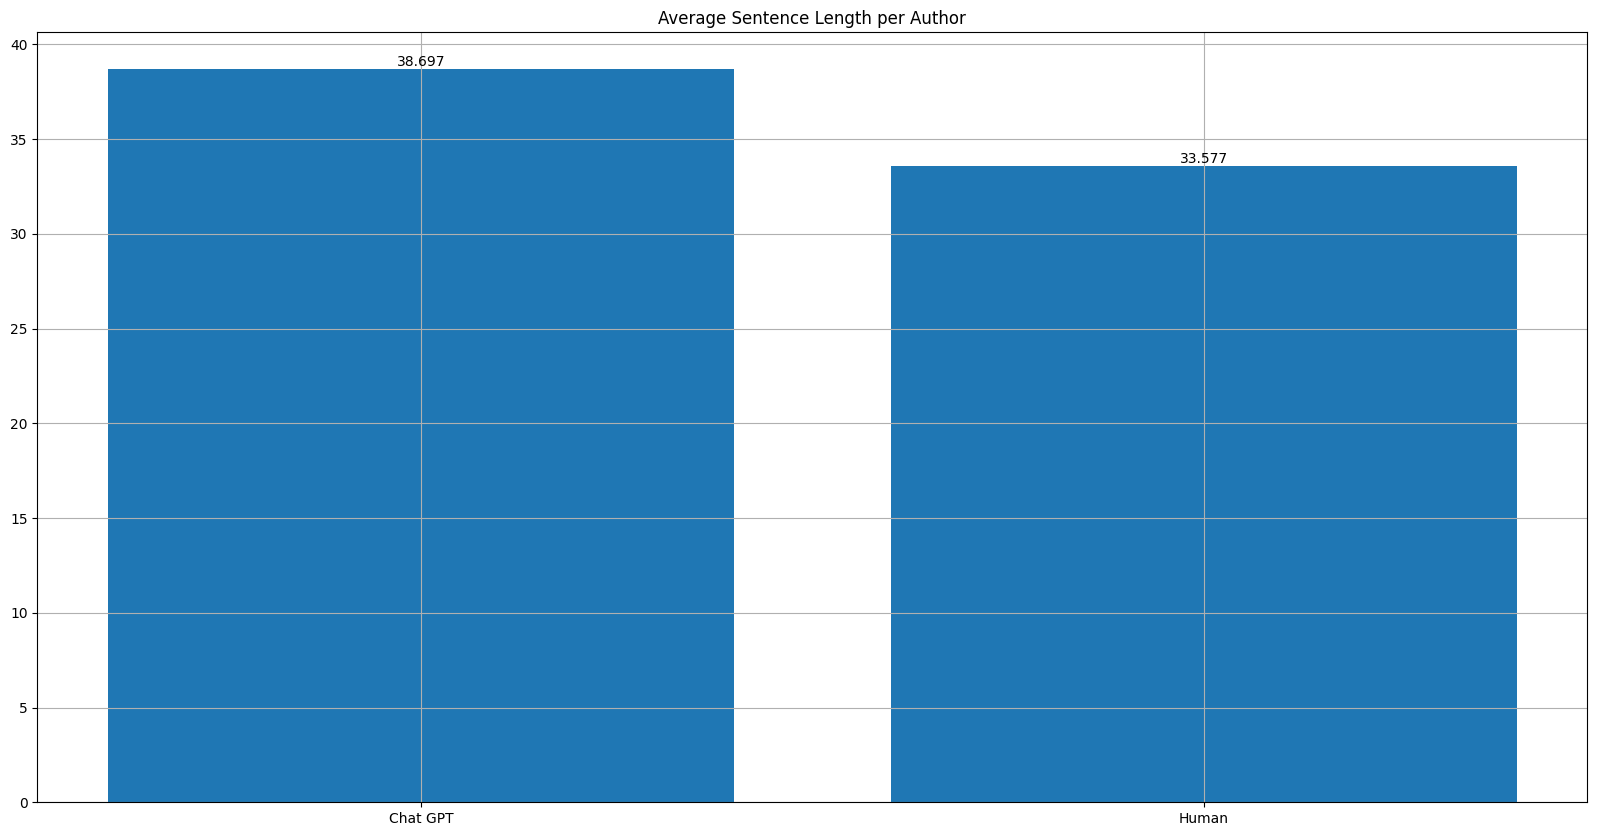

In [ ]:
plt.figure(figsize=(20,10))
bars = plt.bar(['Chat GPT', 'Human'], [answer_average_sentence_length(index_to_chatgpt_answer), answer_average_sentence_length(index_to_human_answer)])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Average Sentence Length per Author')
plt.grid(True)
plt.show()

**Most frequent words**

In [ ]:
from collections import Counter
from wordcloud import WordCloud

In [ ]:
def get_top_n_words(words: list, n: int) -> list:
    return Counter(words).most_common(n)

In [ ]:
def plot_word_cloud(words: list):
    text = " ".join(words)

    wc = WordCloud(width=3000, height=2000, background_color='white')
    wc.generate(text)

    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [ ]:
chat_gpt_corpus = ""

for _, answer in index_to_chatgpt_answer.items():
    chat_gpt_corpus += answer

chat_gpt_corpus = chat_gpt_corpus.lower()
chat_gpt_corpus = remove_punctuation(chat_gpt_corpus)
chat_gpt_corpus

'animal cognition refers to the mental capacities of nonhuman animals it includes the ability to process information perceive and attend to stimuli learn and remember solve problems and make decisions these cognitive abilities are thought to be mediated by brain functions and research on animal cognition seeks to understand the neural and psychological mechanisms underlying these abilitiesnnnnstudies of animal cognition have been conducted in a variety of species including mammals birds reptiles and fish these studies have revealed that many animals are capable of sophisticated cognitive abilities such as problemsolving learning and decisionmaking for example some animals are able to use tools communicate with others and navigate complex environmentsnnnnunderstanding animal cognition can provide insight into the evolution of cognitive abilities in humans and other animals and can also inform the development of animalfriendly practices in fields such as animal welfare conservation and a

In [ ]:
word_list_chat_gpt = []
frequencies_chat_gpt = []

for word, frequency in get_top_n_words(chat_gpt_corpus.split(), 20):
    word_list_chat_gpt.append(word)
    frequencies_chat_gpt.append(frequency)


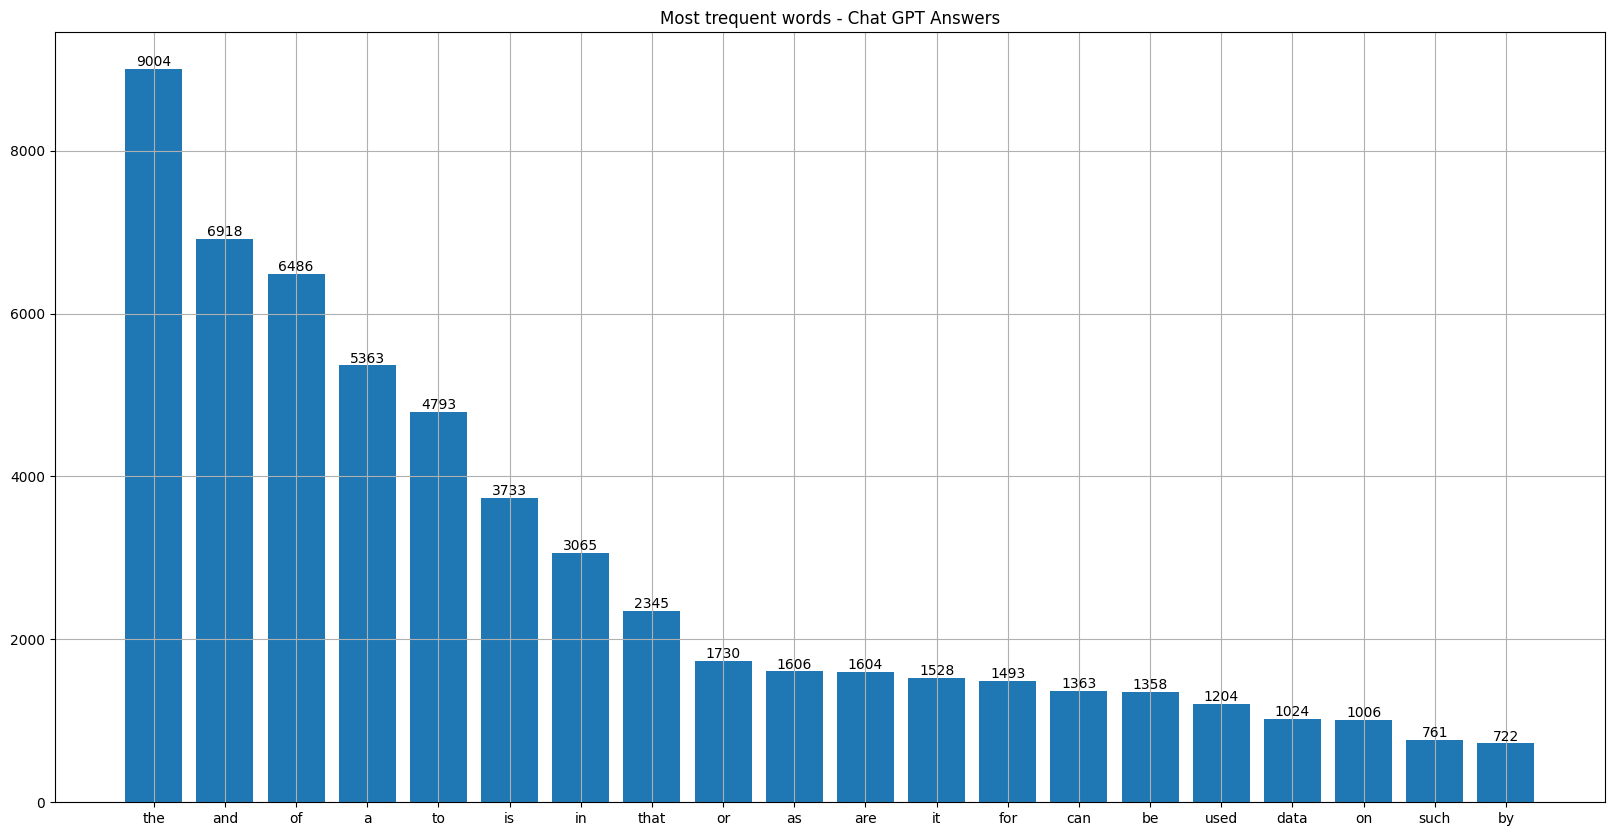

In [ ]:
plt.figure(figsize=(20,10))
bars = plt.bar(word_list_chat_gpt, frequencies_chat_gpt)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Most trequent words - Chat GPT Answers')
plt.grid(True)
plt.show()

In [ ]:
human_corpus = ""

for _, answer in index_to_human_answer.items():
    human_corpus += answer

human_corpus = human_corpus.lower()
human_corpus = remove_punctuation(human_corpus)
human_corpus

'animal cognition encompasses the mental capacities of nonhuman animals including insect cognition the study of animal conditioning and learning used in this field was developed from comparative psychology it has also been strongly influenced by research in ethology behavioral ecology and evolutionary psychology  the alternative name cognitive ethology is sometimes used many behaviors associated with the term animal intelligence are also subsumed within animal cognitionnresearchers have examined animal cognition in mammals especially primates cetaceans elephants dogs cats pigs horses cattle raccoons and rodents birds including parrots fowl corvids and pigeons reptiles lizards snakes and turtles fish and invertebrates including cephalopods spiders and insectsbhuman intelligence is the intellectual capability of humans which is marked by complex cognitive feats and high levels of motivation and selfawareness high intelligence is associated with better outcomes in lifenthrough intelligenc

In [ ]:
word_list_human = []
frequencies_human = []

for word, frequency in get_top_n_words(human_corpus.split(), 20):
    word_list_human.append(word)
    frequencies_human.append(frequency)

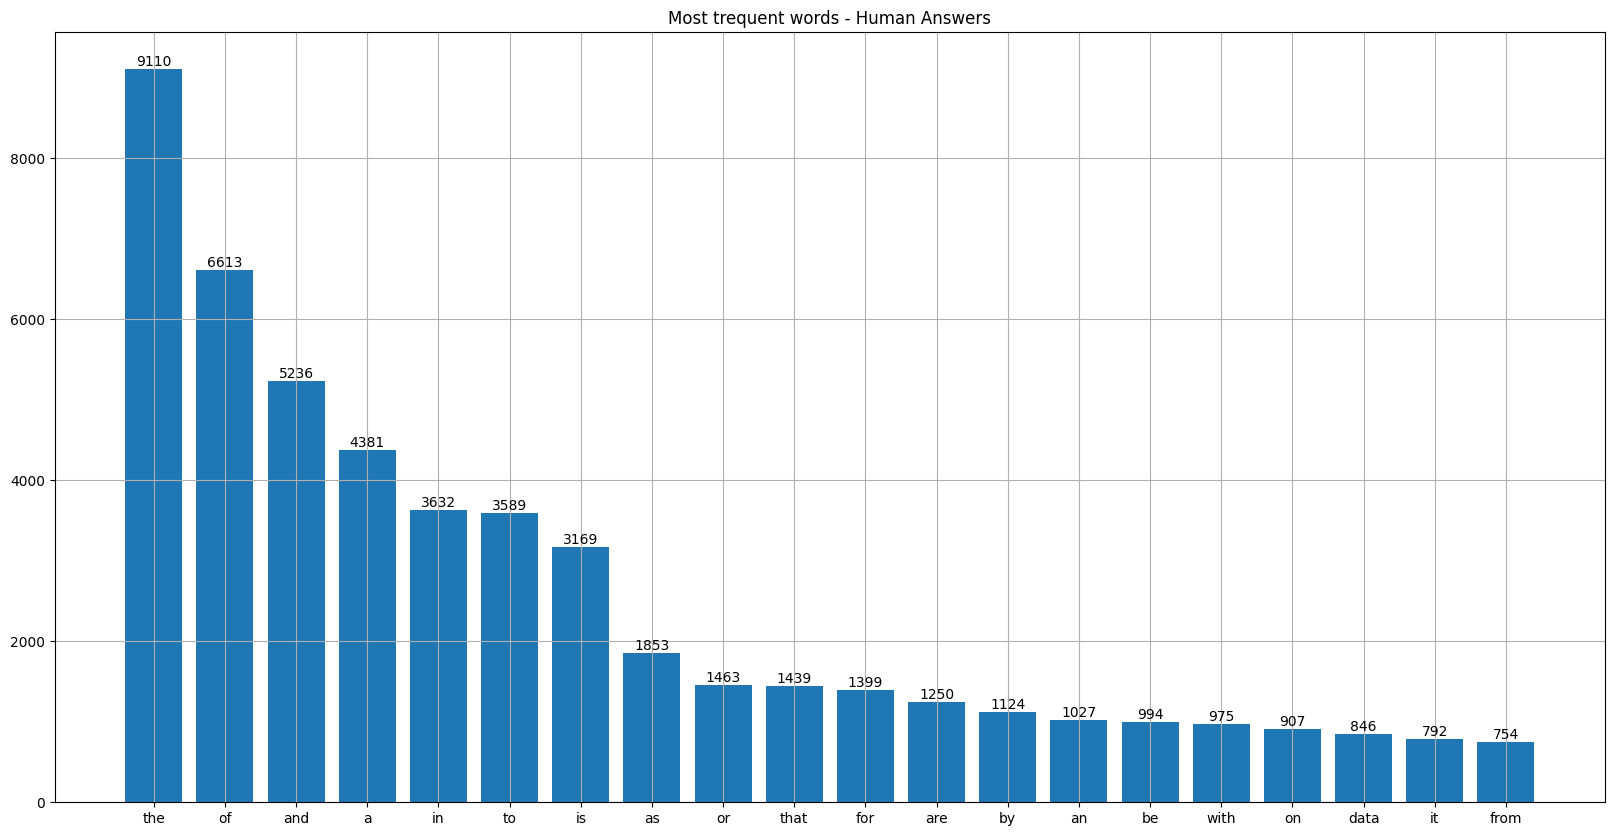

In [ ]:
plt.figure(figsize=(20,10))
bars = plt.bar(word_list_human, frequencies_human)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Most trequent words - Human Answers')
plt.grid(True)
plt.show()

**Most frequent words without stopwords**

In [ ]:
chat_gpt_corpus_without_stopwords = remove_stop_words(chat_gpt_corpus.split())

chat_gpt_most_frequent_without_stopwords = get_top_n_words(chat_gpt_corpus_without_stopwords, 20)
word_list_chat_gpt_without_stopwords = []
frequencies_chat_gpt_without_stopwords = []

for word, frequency in chat_gpt_most_frequent_without_stopwords:
    word_list_chat_gpt_without_stopwords.append(word)
    frequencies_chat_gpt_without_stopwords.append(frequency)




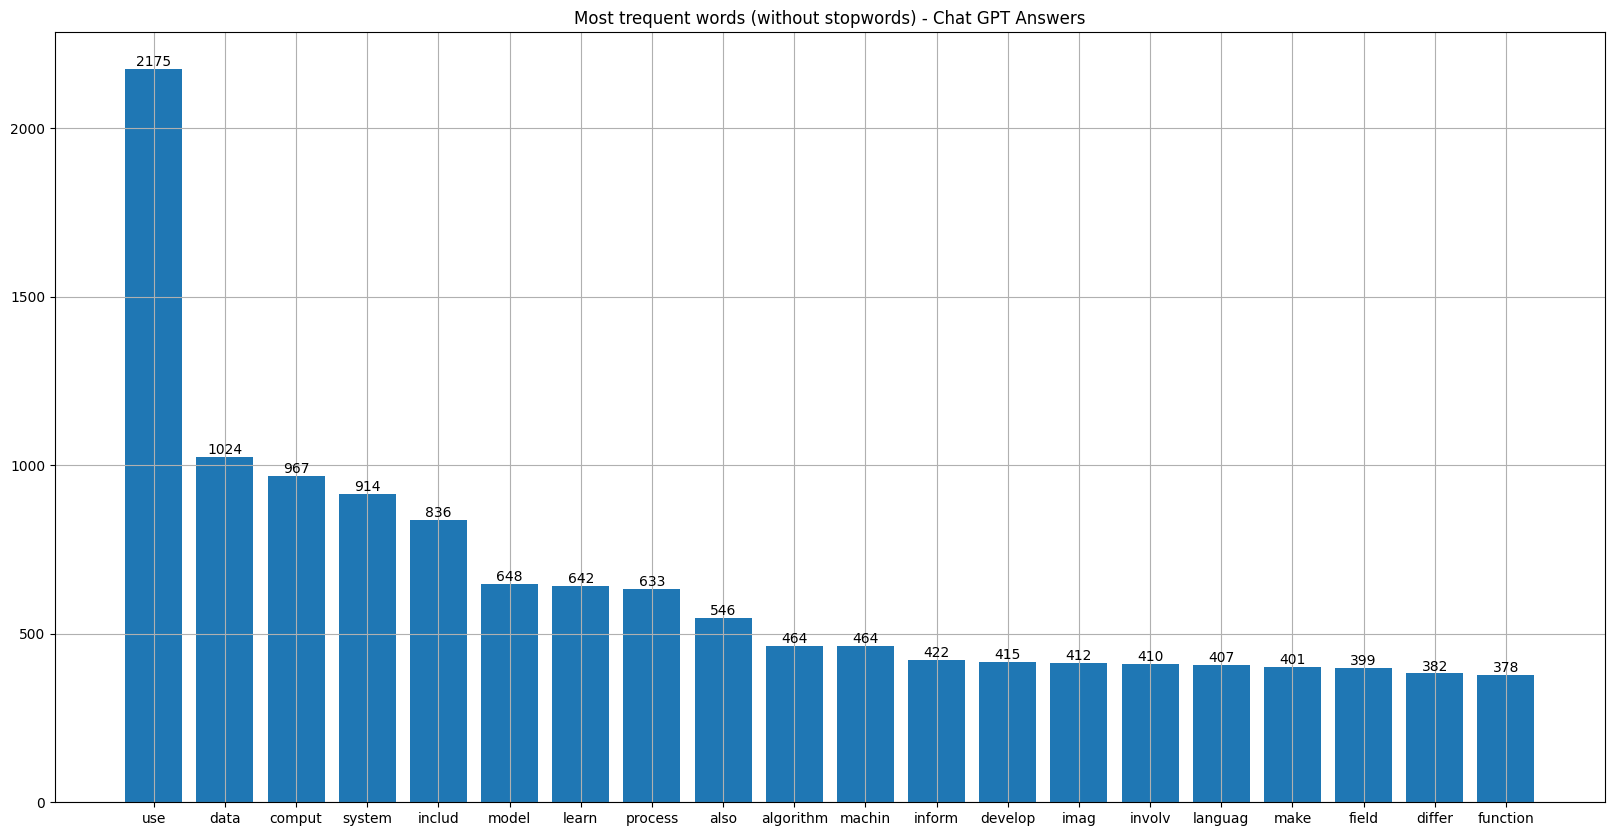

In [ ]:
plt.figure(figsize=(20,10))
bars = plt.bar(word_list_chat_gpt_without_stopwords, frequencies_chat_gpt_without_stopwords)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Most trequent words (without stopwords) - Chat GPT Answers')
plt.grid(True)
plt.show()

In [ ]:
human_corpus_without_stopwords = remove_stop_words(human_corpus.split())

human_most_frequent_without_stopwords = get_top_n_words(human_corpus_without_stopwords, 20)
word_list_human_without_stopwords = []
frequencies_human_without_stopwords = []

for word, frequency in human_most_frequent_without_stopwords:
    word_list_human_without_stopwords.append(word)
    frequencies_human_without_stopwords.append(frequency)

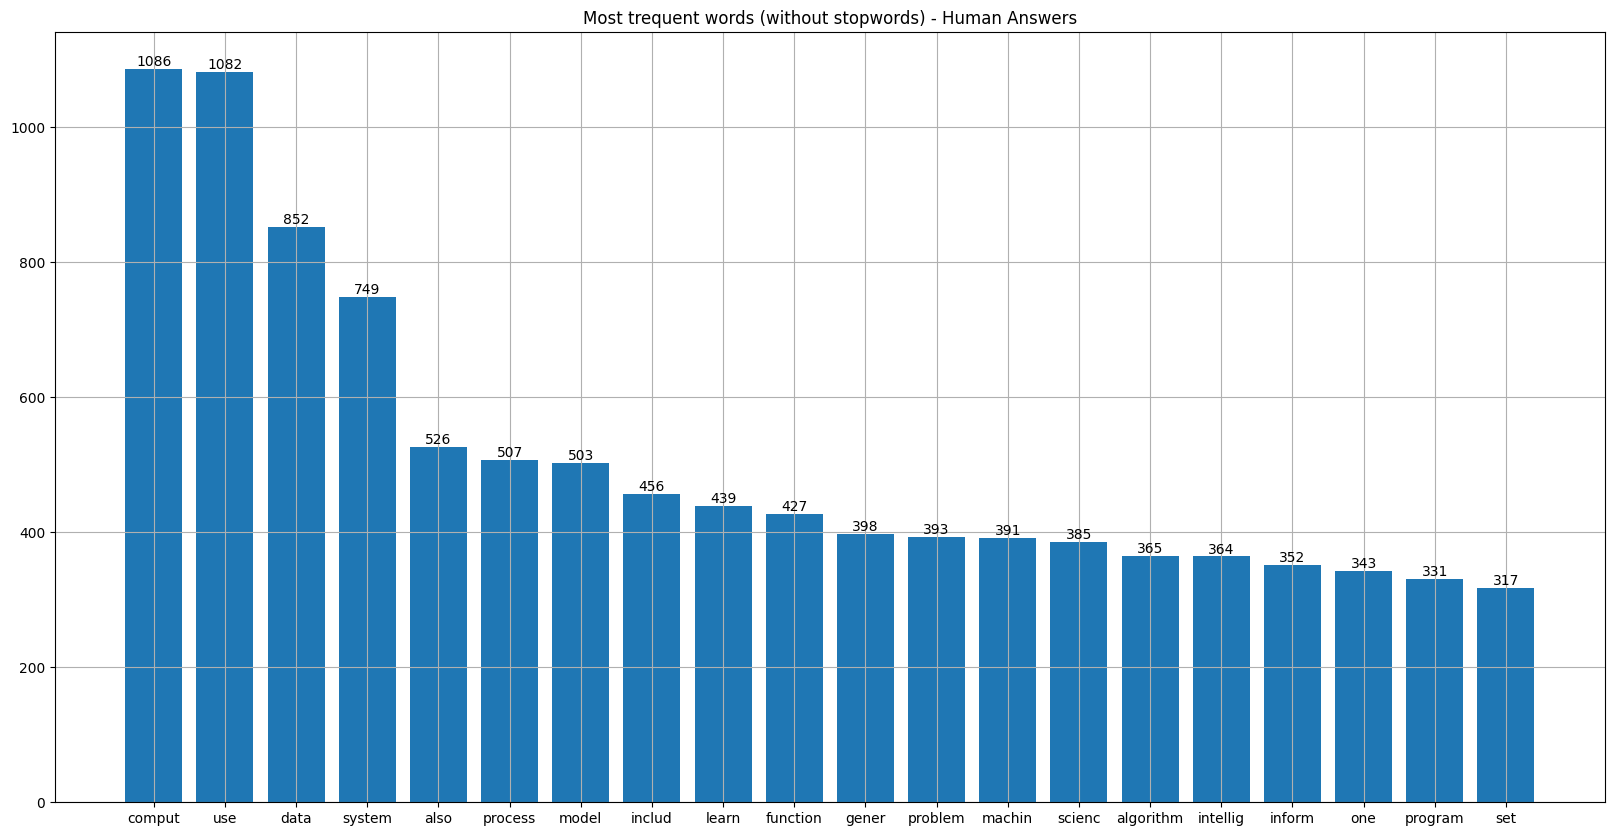

In [ ]:
plt.figure(figsize=(20,10))
bars = plt.bar(word_list_human_without_stopwords, frequencies_human_without_stopwords)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{round(height, 3)}",
        ha="center",
        va="bottom"
    )
plt.title('Most trequent words (without stopwords) - Human Answers')
plt.grid(True)
plt.show()

In [ ]:
word_list_human_without_stopwords

['comput',
 'use',
 'data',
 'system',
 'also',
 'process',
 'model',
 'includ',
 'learn',
 'function',
 'gener',
 'problem',
 'machin',
 'scienc',
 'algorithm',
 'intellig',
 'inform',
 'one',
 'program',
 'set']

In [ ]:
word_list_chat_gpt_without_stopwords

['use',
 'data',
 'comput',
 'system',
 'includ',
 'model',
 'learn',
 'process',
 'also',
 'algorithm',
 'machin',
 'inform',
 'develop',
 'imag',
 'involv',
 'languag',
 'make',
 'field',
 'differ',
 'function']

In [ ]:
intersection = list(set(word_list_human_without_stopwords) & set(word_list_chat_gpt_without_stopwords))
intersection

['function',
 'use',
 'model',
 'comput',
 'data',
 'inform',
 'includ',
 'process',
 'system',
 'also',
 'learn',
 'machin',
 'algorithm']

**Type token ratio**

Closer to 1 -> more diverse \
Closer to 0 -> more repetitive



In [ ]:
chat_gpt_vocab = set(chat_gpt_corpus.split())
chat_gpt_type_token_ratio = len(chat_gpt_vocab) / len(chat_gpt_corpus.split())
chat_gpt_type_token_ratio

0.07326740444235147

In [ ]:
human_vocab = set(human_corpus.split())
human_type_token_ratio = len(human_vocab) / len(human_corpus.split())
human_type_token_ratio

0.10292431725650829

**bold text**